In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# install Hangul font

!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (7,330 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and direc

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

plt.rc('font', family='NanumBarunGothic')

file_path = "/content/태림_필터링데이터(찐).xlsx"

df = pd.read_excel(file_path)

In [2]:
# ID_Release → 날짜 파싱
df['Release_Date'] = pd.to_datetime(df['ID_Release'].str[:8], format='%Y%m%d', errors='coerce')

In [3]:
# 품번별 ID_Release별 통계 집계
pn_list = df['ZF_PN'].unique()

stats = (
    df.groupby(['ZF_PN', 'Release_Date'])['Quantity']
    .agg(mean='mean', median='median', count='count')
    .reset_index()
    .sort_values(['ZF_PN', 'Release_Date'])
)

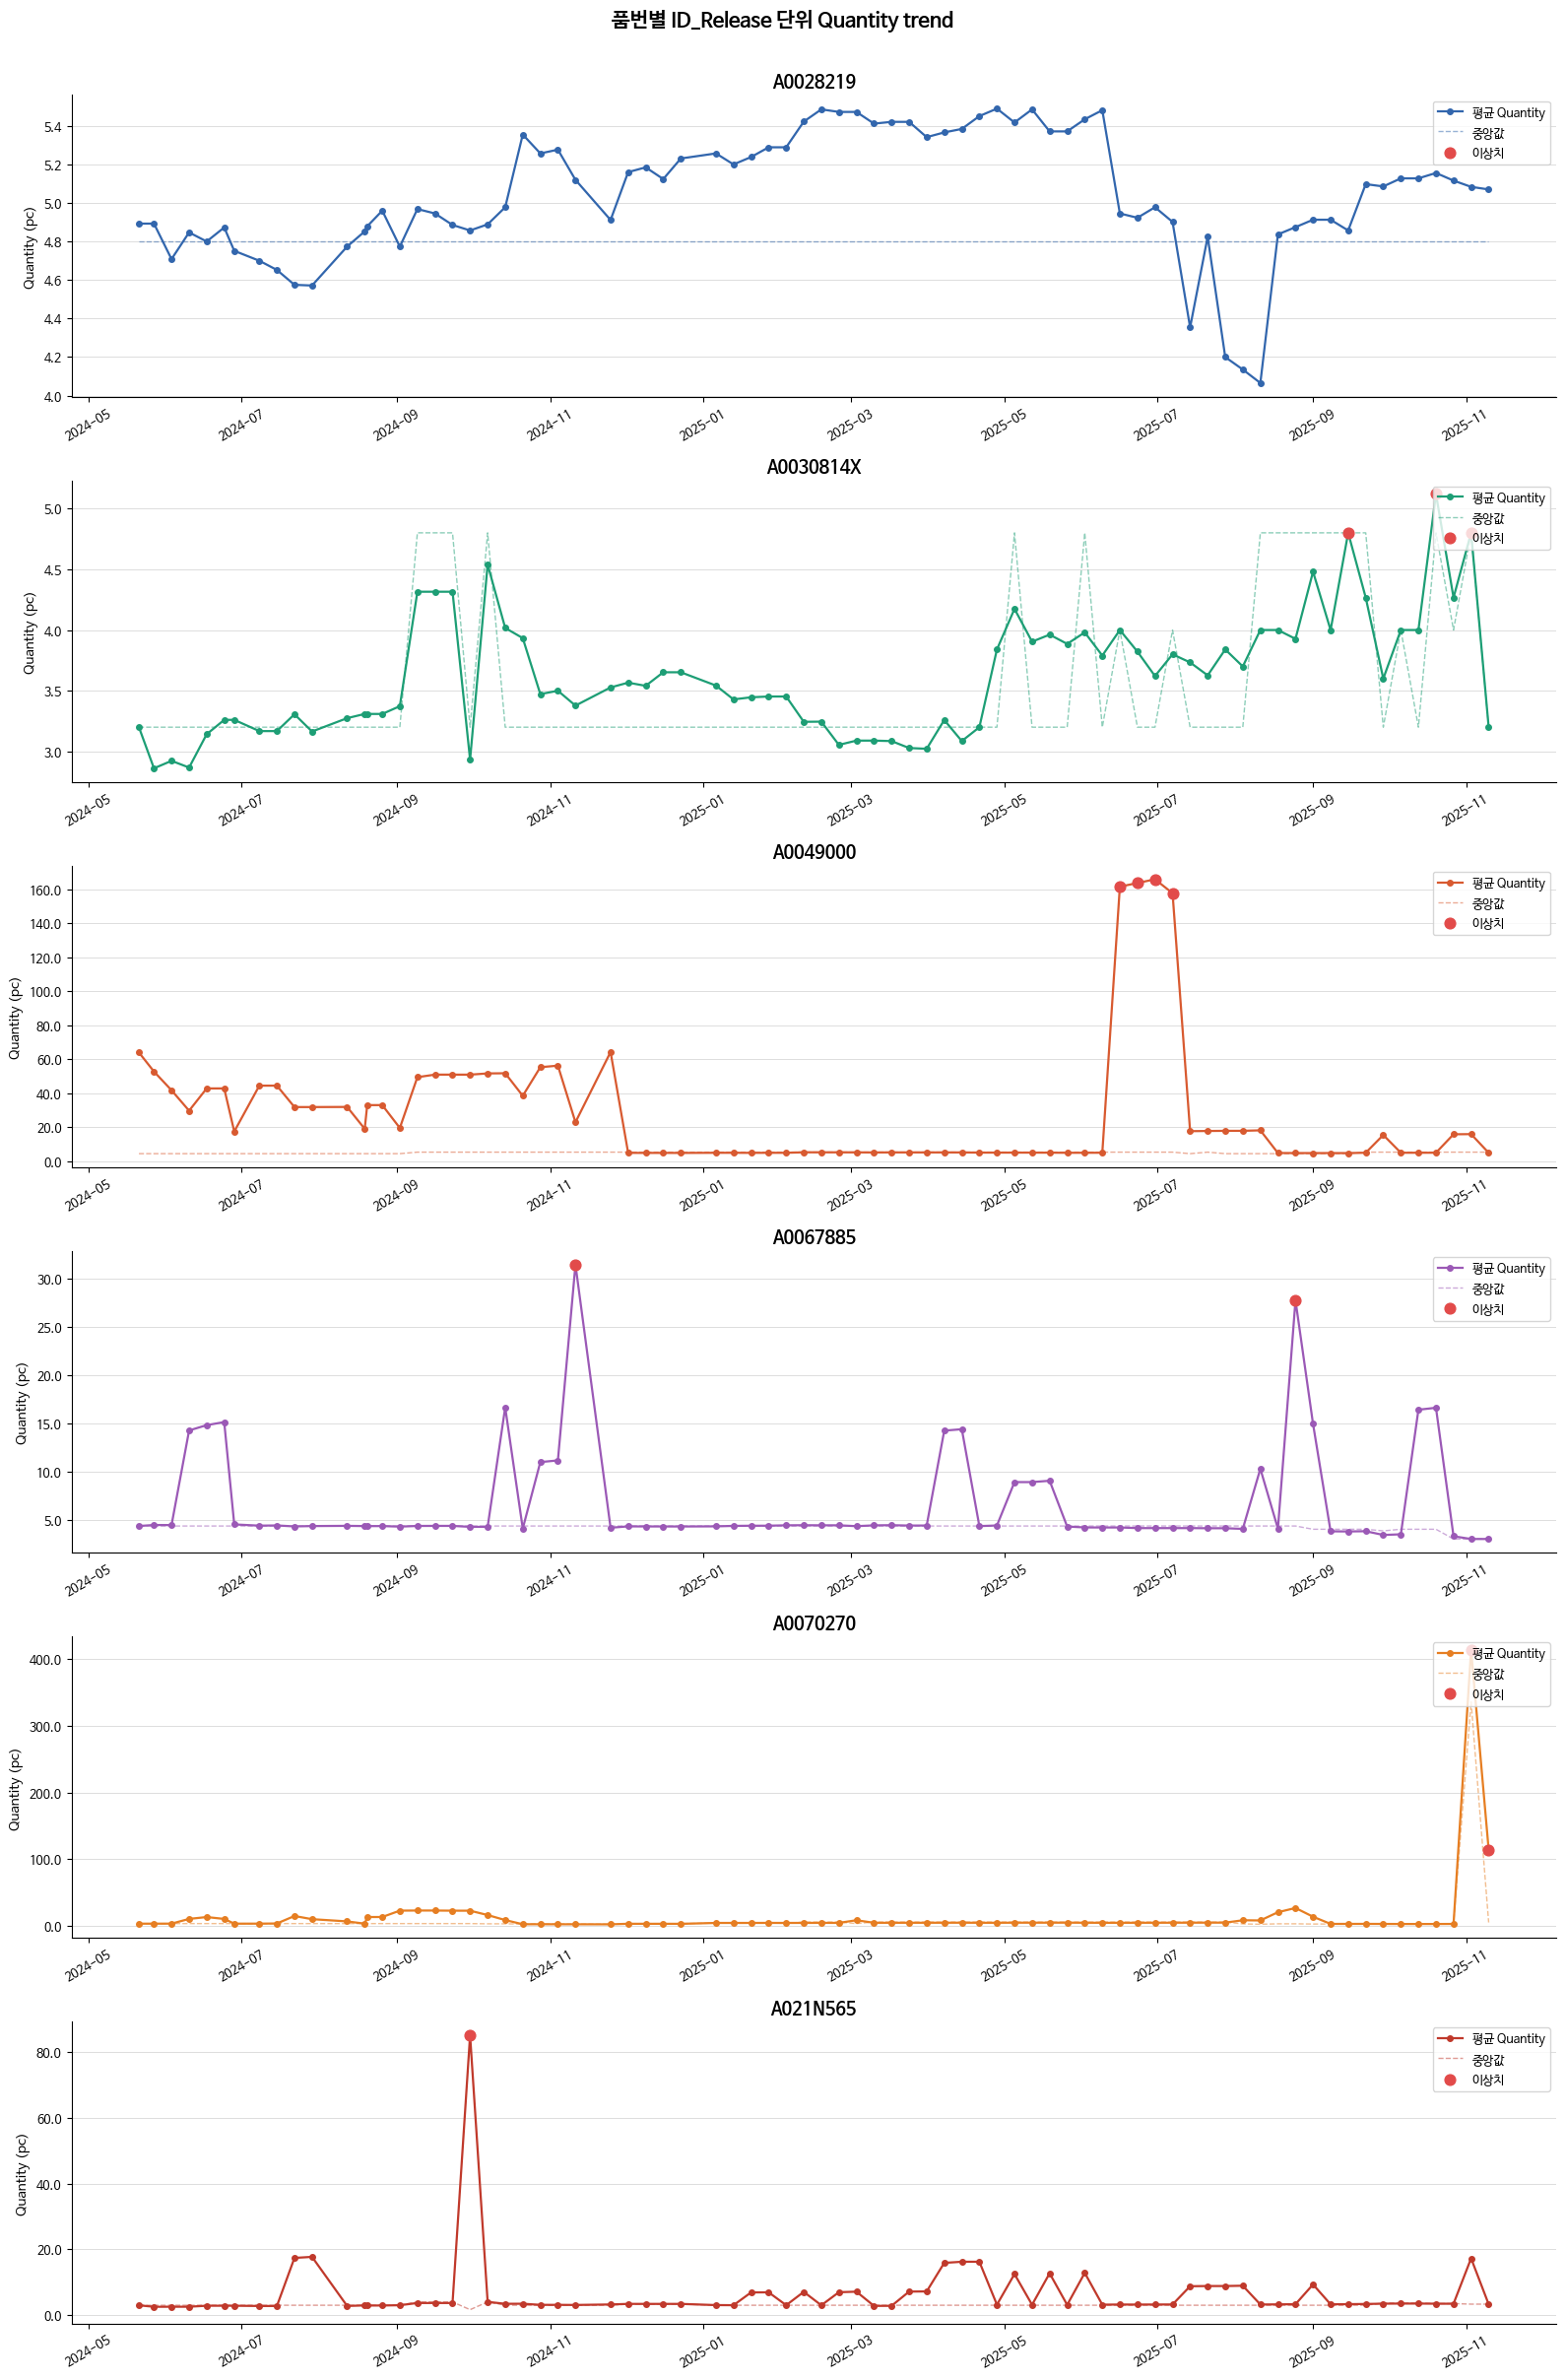

In [4]:
# 시각화
fig, axes = plt.subplots(len(pn_list), 1, figsize=(16, 4 * len(pn_list)), sharex=False)

colors = {
    'A0028219':  '#3266ad',
    'A0030814X': '#1D9E75',
    'A0049000':  '#D85A30',
    'A0067885':  '#9B59B6',
    'A0070270':  '#E67E22',
    'A021N565':  '#C0392B',
}

for ax, pn in zip(axes, pn_list):
    sub = stats[stats['ZF_PN'] == pn]
    color = colors.get(pn, '#555')

    # 평균 Quantity 선 + 점
    ax.plot(sub['Release_Date'], sub['mean'], color=color,
            linewidth=1.6, marker='o', markersize=4, label='평균 Quantity')

    # 중앙값 선 (점선)
    ax.plot(sub['Release_Date'], sub['median'], color=color,
            linewidth=1, linestyle='--', alpha=0.5, label='중앙값')

 # 이상치 강조 (평균이 전체 평균+2σ 이상인 포인트)
    threshold = sub['mean'].mean() + 2 * sub['mean'].std()
    outliers = sub[sub['mean'] > threshold]
    ax.scatter(outliers['Release_Date'], outliers['mean'],
               color='#E24B4A', s=60, zorder=5, label='이상치')

    ax.set_title(f'{pn}', fontsize=13, fontweight='bold', pad=6)
    ax.set_ylabel('Quantity (pc)', fontsize=10)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(axis='y', color='#ddd', linewidth=0.7)
    ax.tick_params(axis='x', rotation=30, labelsize=9)
    ax.tick_params(axis='y', labelsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('품번별 ID_Release 단위 Quantity trend', fontsize=15, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig('trend_by_pn.png', dpi=150, bbox_inches='tight')

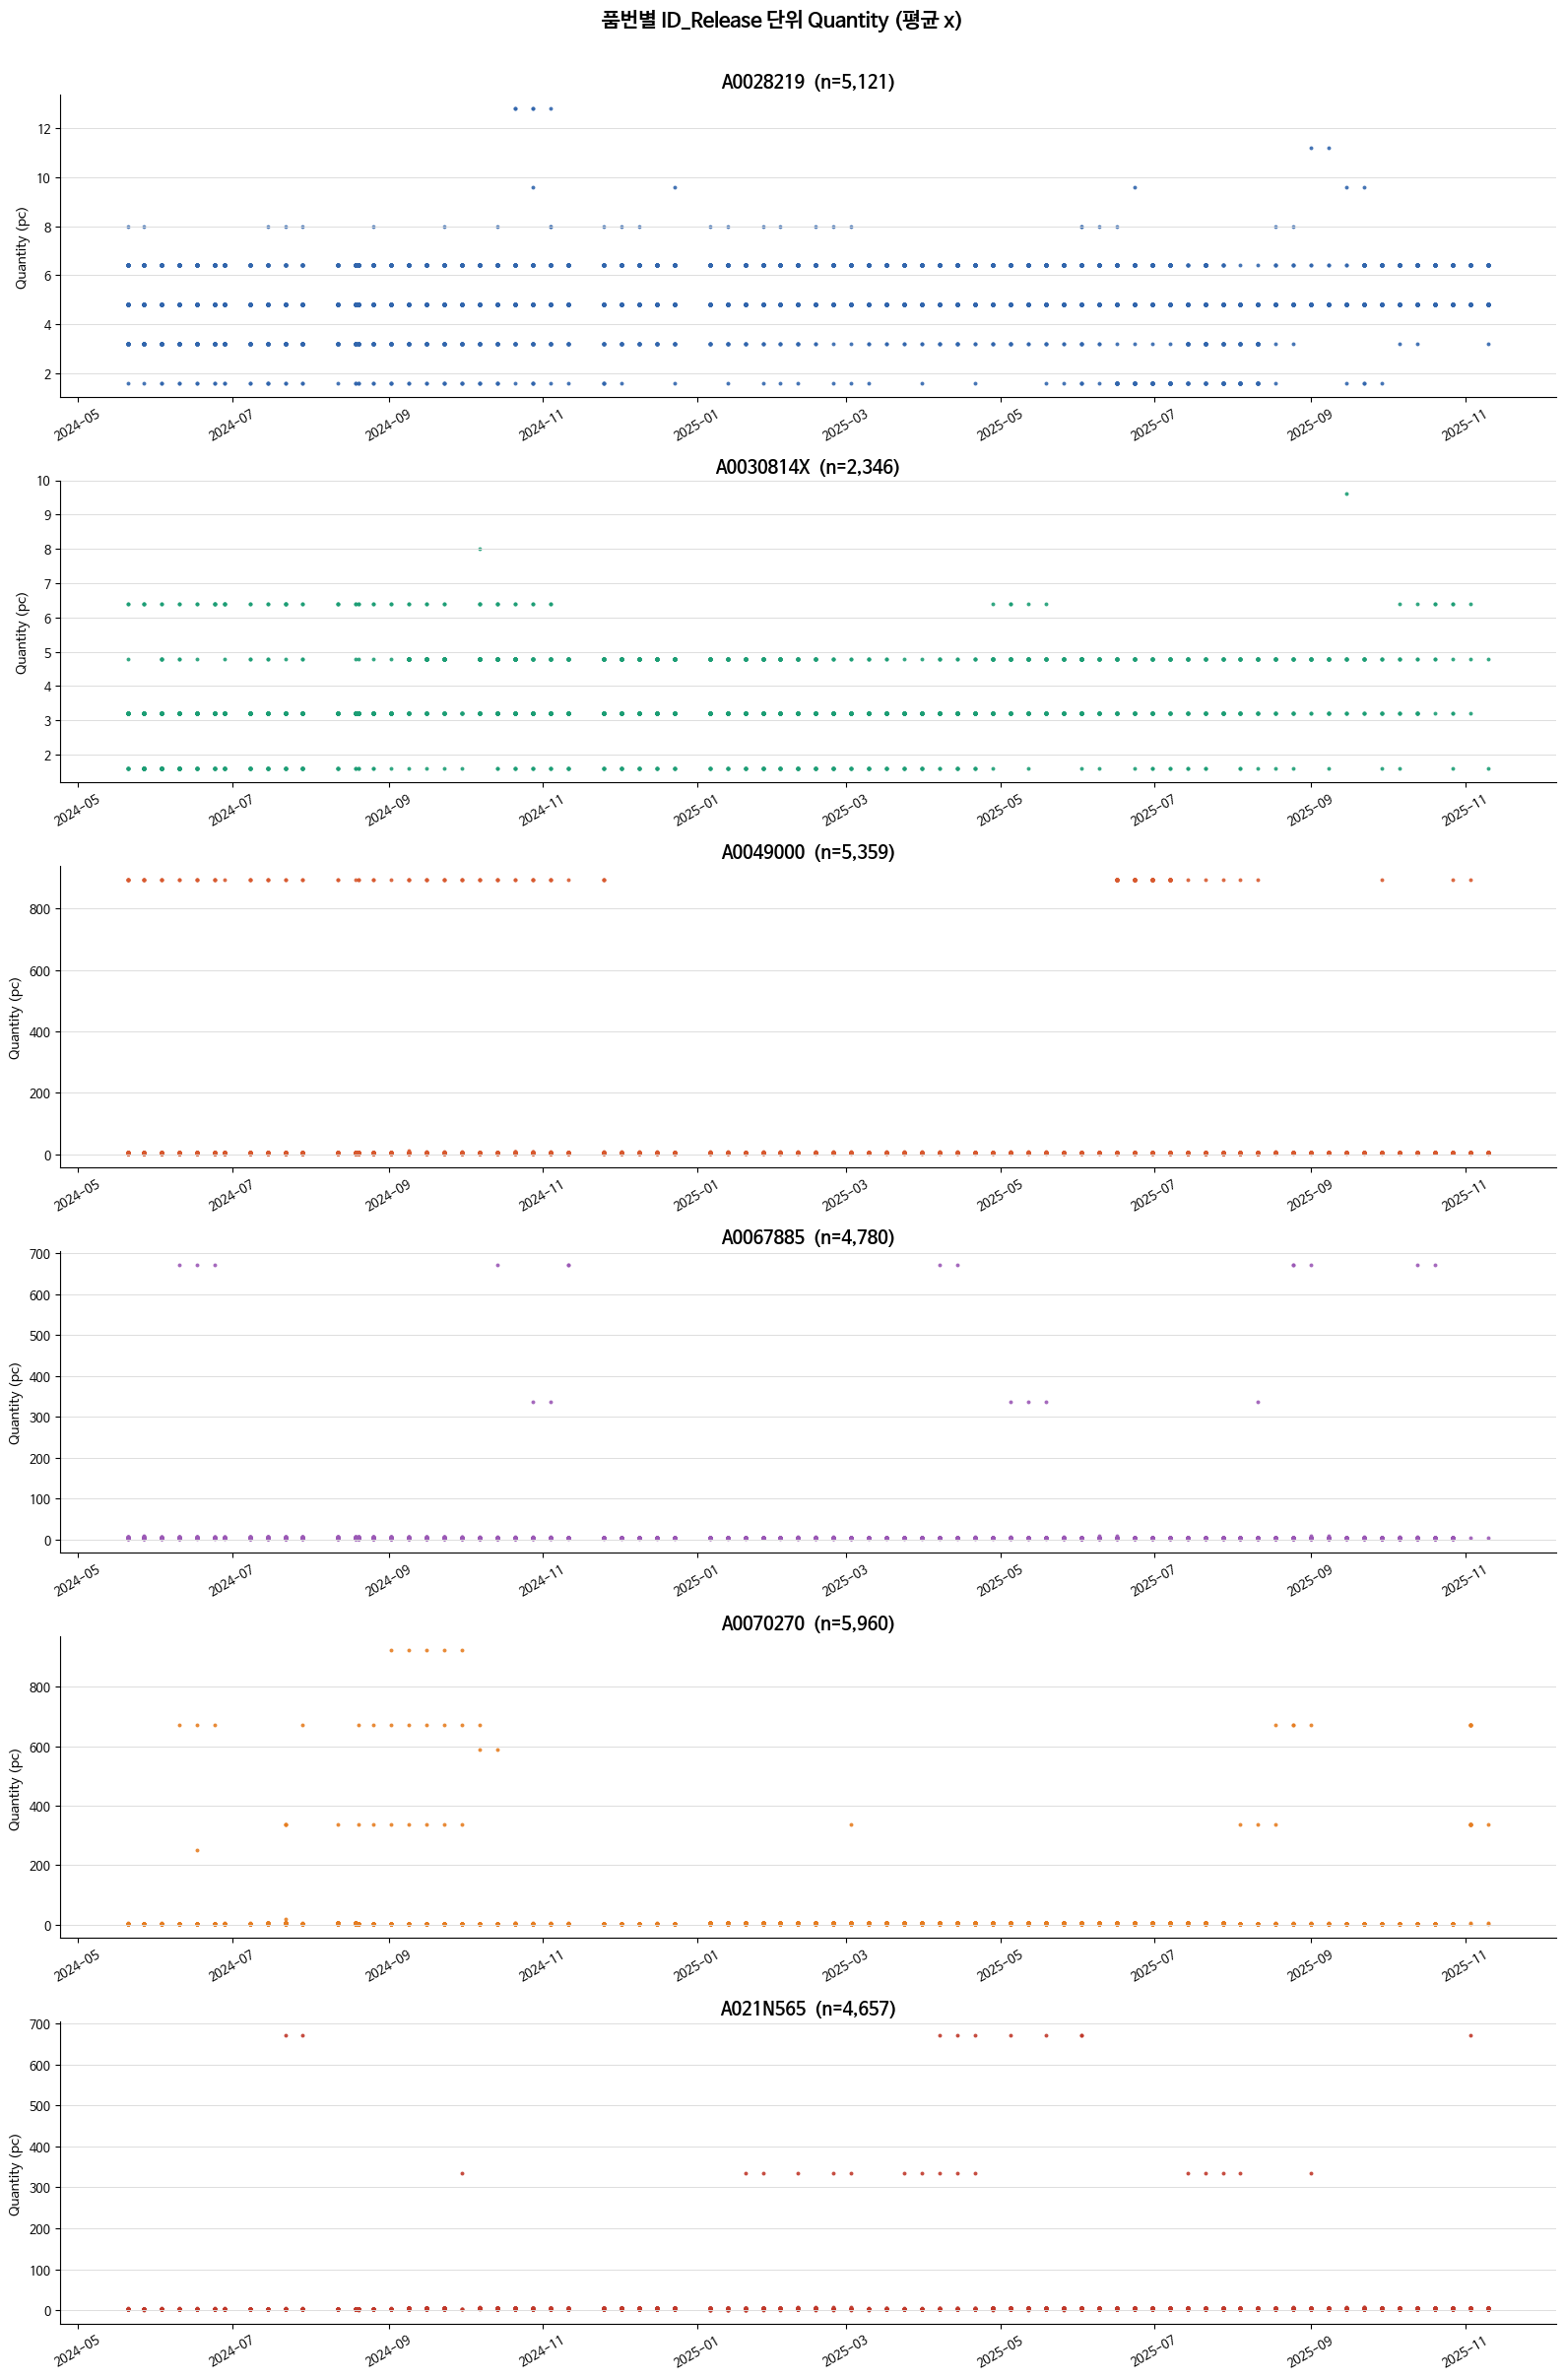

In [6]:

fig, axes = plt.subplots(len(pn_list), 1, figsize=(16, 4 * len(pn_list)), sharex=False)

for ax, pn in zip(axes, pn_list):
    sub = df[df['ZF_PN'] == pn]
    color = colors.get(pn, '#555')

    ax.scatter(
        sub['Release_Date'],
        sub['Quantity'],
        color=color,
        alpha=0.9,      # 점이 많이 겹치므로 투명도 줌
        s=8,            # 점 크기
        linewidths=0,
    )

    ax.set_title(f'{pn}  (n={len(sub):,})', fontsize=13, fontweight='bold', pad=6)
    ax.set_ylabel('Quantity (pc)', fontsize=10)
    ax.tick_params(axis='x', rotation=30, labelsize=9)
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(axis='y', color='#ddd', linewidth=0.7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('품번별 ID_Release 단위 Quantity (평균 x)', fontsize=15, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig('scatter_by_pn.png', dpi=150, bbox_inches='tight')

품번별 Quantity 고유값 및 빈도

[A0028219]  고유값 수: 8
Quantity
1.6      163
3.2      455
4.8     2997
6.4     1468
8.0       26
9.6        5
11.2       2
12.8       5

[A0030814X]  고유값 수: 6
Quantity
1.6     252
3.2    1481
4.8     541
6.4      70
8.0       1
9.6       1

[A0049000]  고유값 수: 20
Quantity
1.760         1
1.792        56
2.688        63
3.552         3
3.584       349
4.256         1
4.480      1975
5.152         2
5.344         6
5.376      2519
5.600         1
6.048        11
6.272       213
7.136         3
7.168        17
8.064         6
8.960         1
9.856         3
10.752        1
896.000     128

[A0067885]  고유값 수: 24
Quantity
1.008        19
1.344        16
1.680        39
2.016        39
2.352        72
2.688        85
3.024       144
3.360       118
3.696       181
4.032       524
4.368      1995
4.704      1315
5.040       106
5.376        60
5.712        29
6.048         7
6.384         2
6.720         4
7.056         1
7.728         1
8.064         2
9.072         2
336

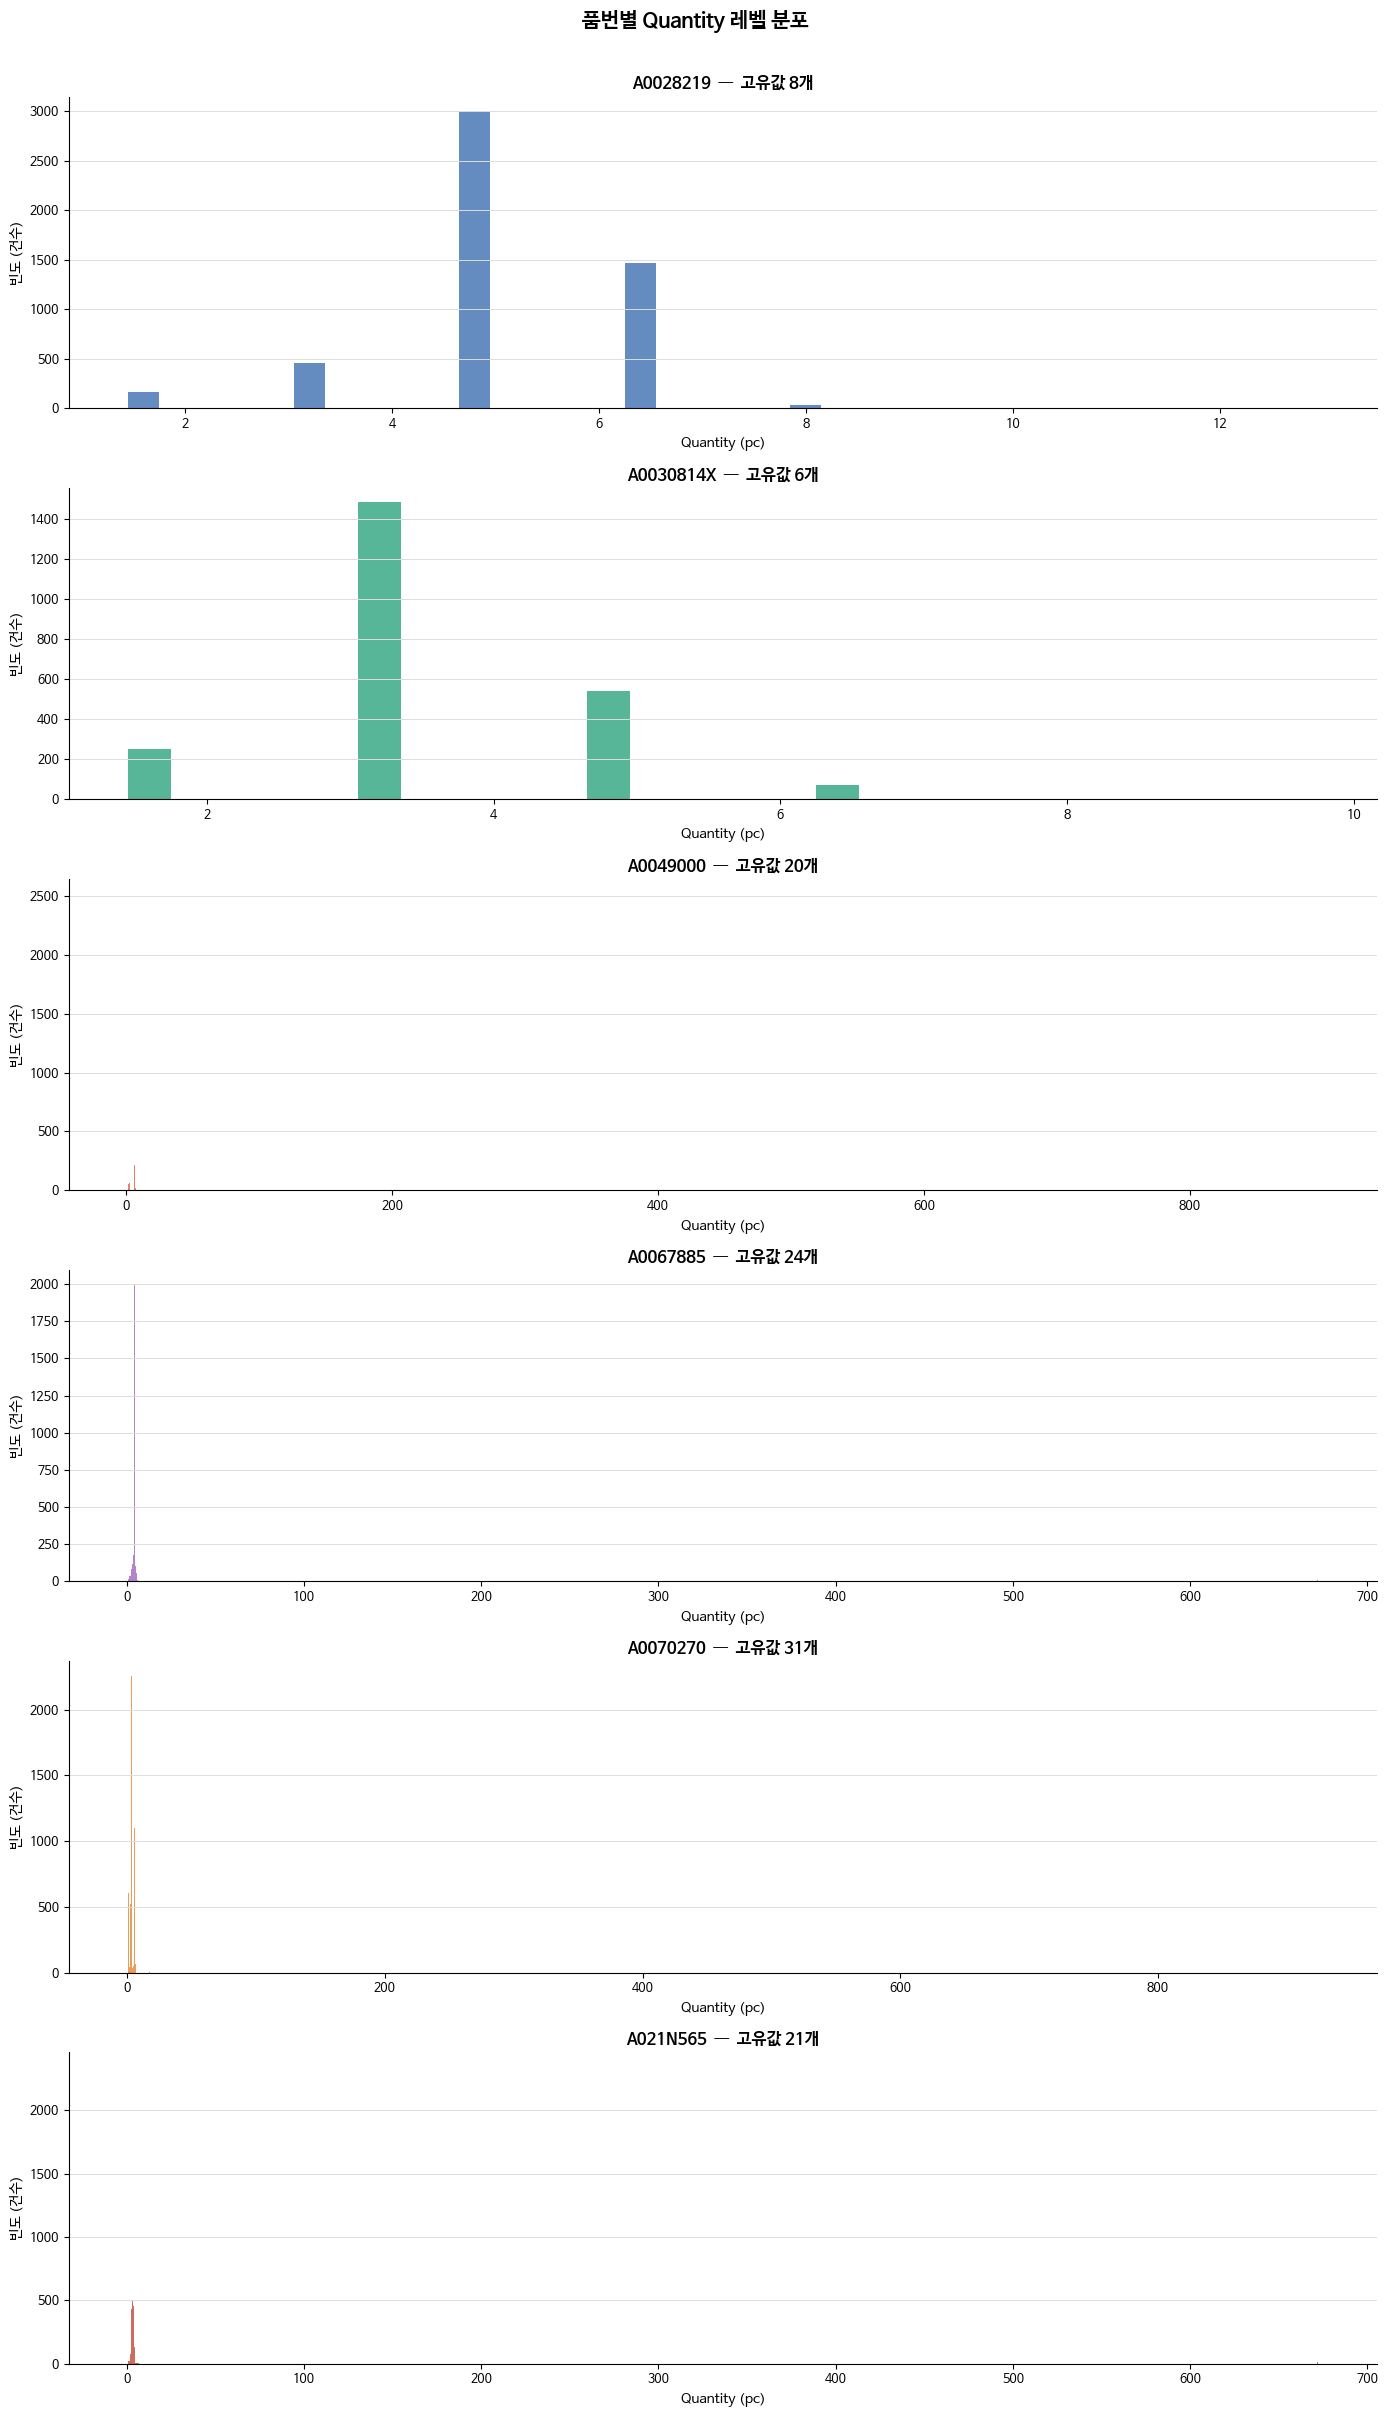


분류 문제 적합성 판단

[A0028219]
  고유값 수       : 8
  상위 3개 레벨   : [4.8, 6.4, 3.2]
  상위 3개 비중   : 96.1%
  → 분류(classification) 접근 적합

[A0030814X]
  고유값 수       : 6
  상위 3개 레벨   : [3.2, 4.8, 1.6]
  상위 3개 비중   : 96.9%
  → 분류(classification) 접근 적합

[A0049000]
  고유값 수       : 20
  상위 3개 레벨   : [5.376, 4.48, 3.584]
  상위 3개 비중   : 90.4%
  → 분류(classification) 접근 적합

[A0067885]
  고유값 수       : 24
  상위 3개 레벨   : [4.368, 4.704, 4.032]
  상위 3개 비중   : 80.2%
  → 고유값이 많아 클러스터링 or 구간화 후 분류 권장

[A0070270]
  고유값 수       : 31
  상위 3개 레벨   : [3.36, 5.712, 1.008]
  상위 3개 비중   : 66.5%
  → 고유값이 많아 클러스터링 or 구간화 후 분류 권장

[A021N565]
  고유값 수       : 21
  상위 3개 레벨   : [3.024, 3.36, 3.696]
  상위 3개 비중   : 70.7%
  → 고유값이 많아 클러스터링 or 구간화 후 분류 권장


In [7]:

#  1. 품번별 Quantity 고유값 & 빈도 출력
print("=" * 60)
print("품번별 Quantity 고유값 및 빈도")
print("=" * 60)
for pn in pn_list:
    sub = df[df['ZF_PN'] == pn]
    val_counts = sub['Quantity'].value_counts().sort_index()
    print(f"\n[{pn}]  고유값 수: {sub['Quantity'].nunique()}")
    print(val_counts.to_string())

#  2. 품번별 Quantity 분포 히스토그램
fig, axes = plt.subplots(len(pn_list), 1, figsize=(14, 4 * len(pn_list)), sharex=False)

for ax, pn in zip(axes, pn_list):
    sub = df[df['ZF_PN'] == pn]
    color = colors.get(pn, '#555')
    val_counts = sub['Quantity'].value_counts().sort_index()

    ax.bar(val_counts.index, val_counts.values, color=color, alpha=0.75, width=0.3)
    ax.set_title(f'{pn}  —  고유값 {sub["Quantity"].nunique()}개', fontsize=12, fontweight='bold')
    ax.set_xlabel('Quantity (pc)', fontsize=10)
    ax.set_ylabel('빈도 (건수)', fontsize=10)
    ax.tick_params(labelsize=9)
    ax.grid(axis='y', color='#ddd', linewidth=0.7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('품번별 Quantity 레벨 분포', fontsize=15, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig('quantity_levels.png', dpi=150, bbox_inches='tight')
print("\n저장 완료: quantity_levels.png")
plt.show()


print("\n" + "=" * 60)
print("분류 문제 적합성 판단")
print("=" * 60)
for pn in pn_list:
    sub = df[df['ZF_PN'] == pn]
    n_unique = sub['Quantity'].nunique()
    top3 = sub['Quantity'].value_counts().head(3)
    top3_ratio = top3.sum() / len(sub) * 100
    print(f"\n[{pn}]")
    print(f"  고유값 수       : {n_unique}")
    print(f"  상위 3개 레벨   : {top3.index.tolist()}")
    print(f"  상위 3개 비중   : {top3_ratio:.1f}%")
    if n_unique <= 20:
        print(f"  → 분류(classification) 접근 적합")
    else:
        print(f"  → 고유값이 많아 클러스터링 or 구간화 후 분류 권장")

# Year, Month, Day 기준(x축) Forecast/Firm Quantity, Forecast/Firm 비율 알아보기

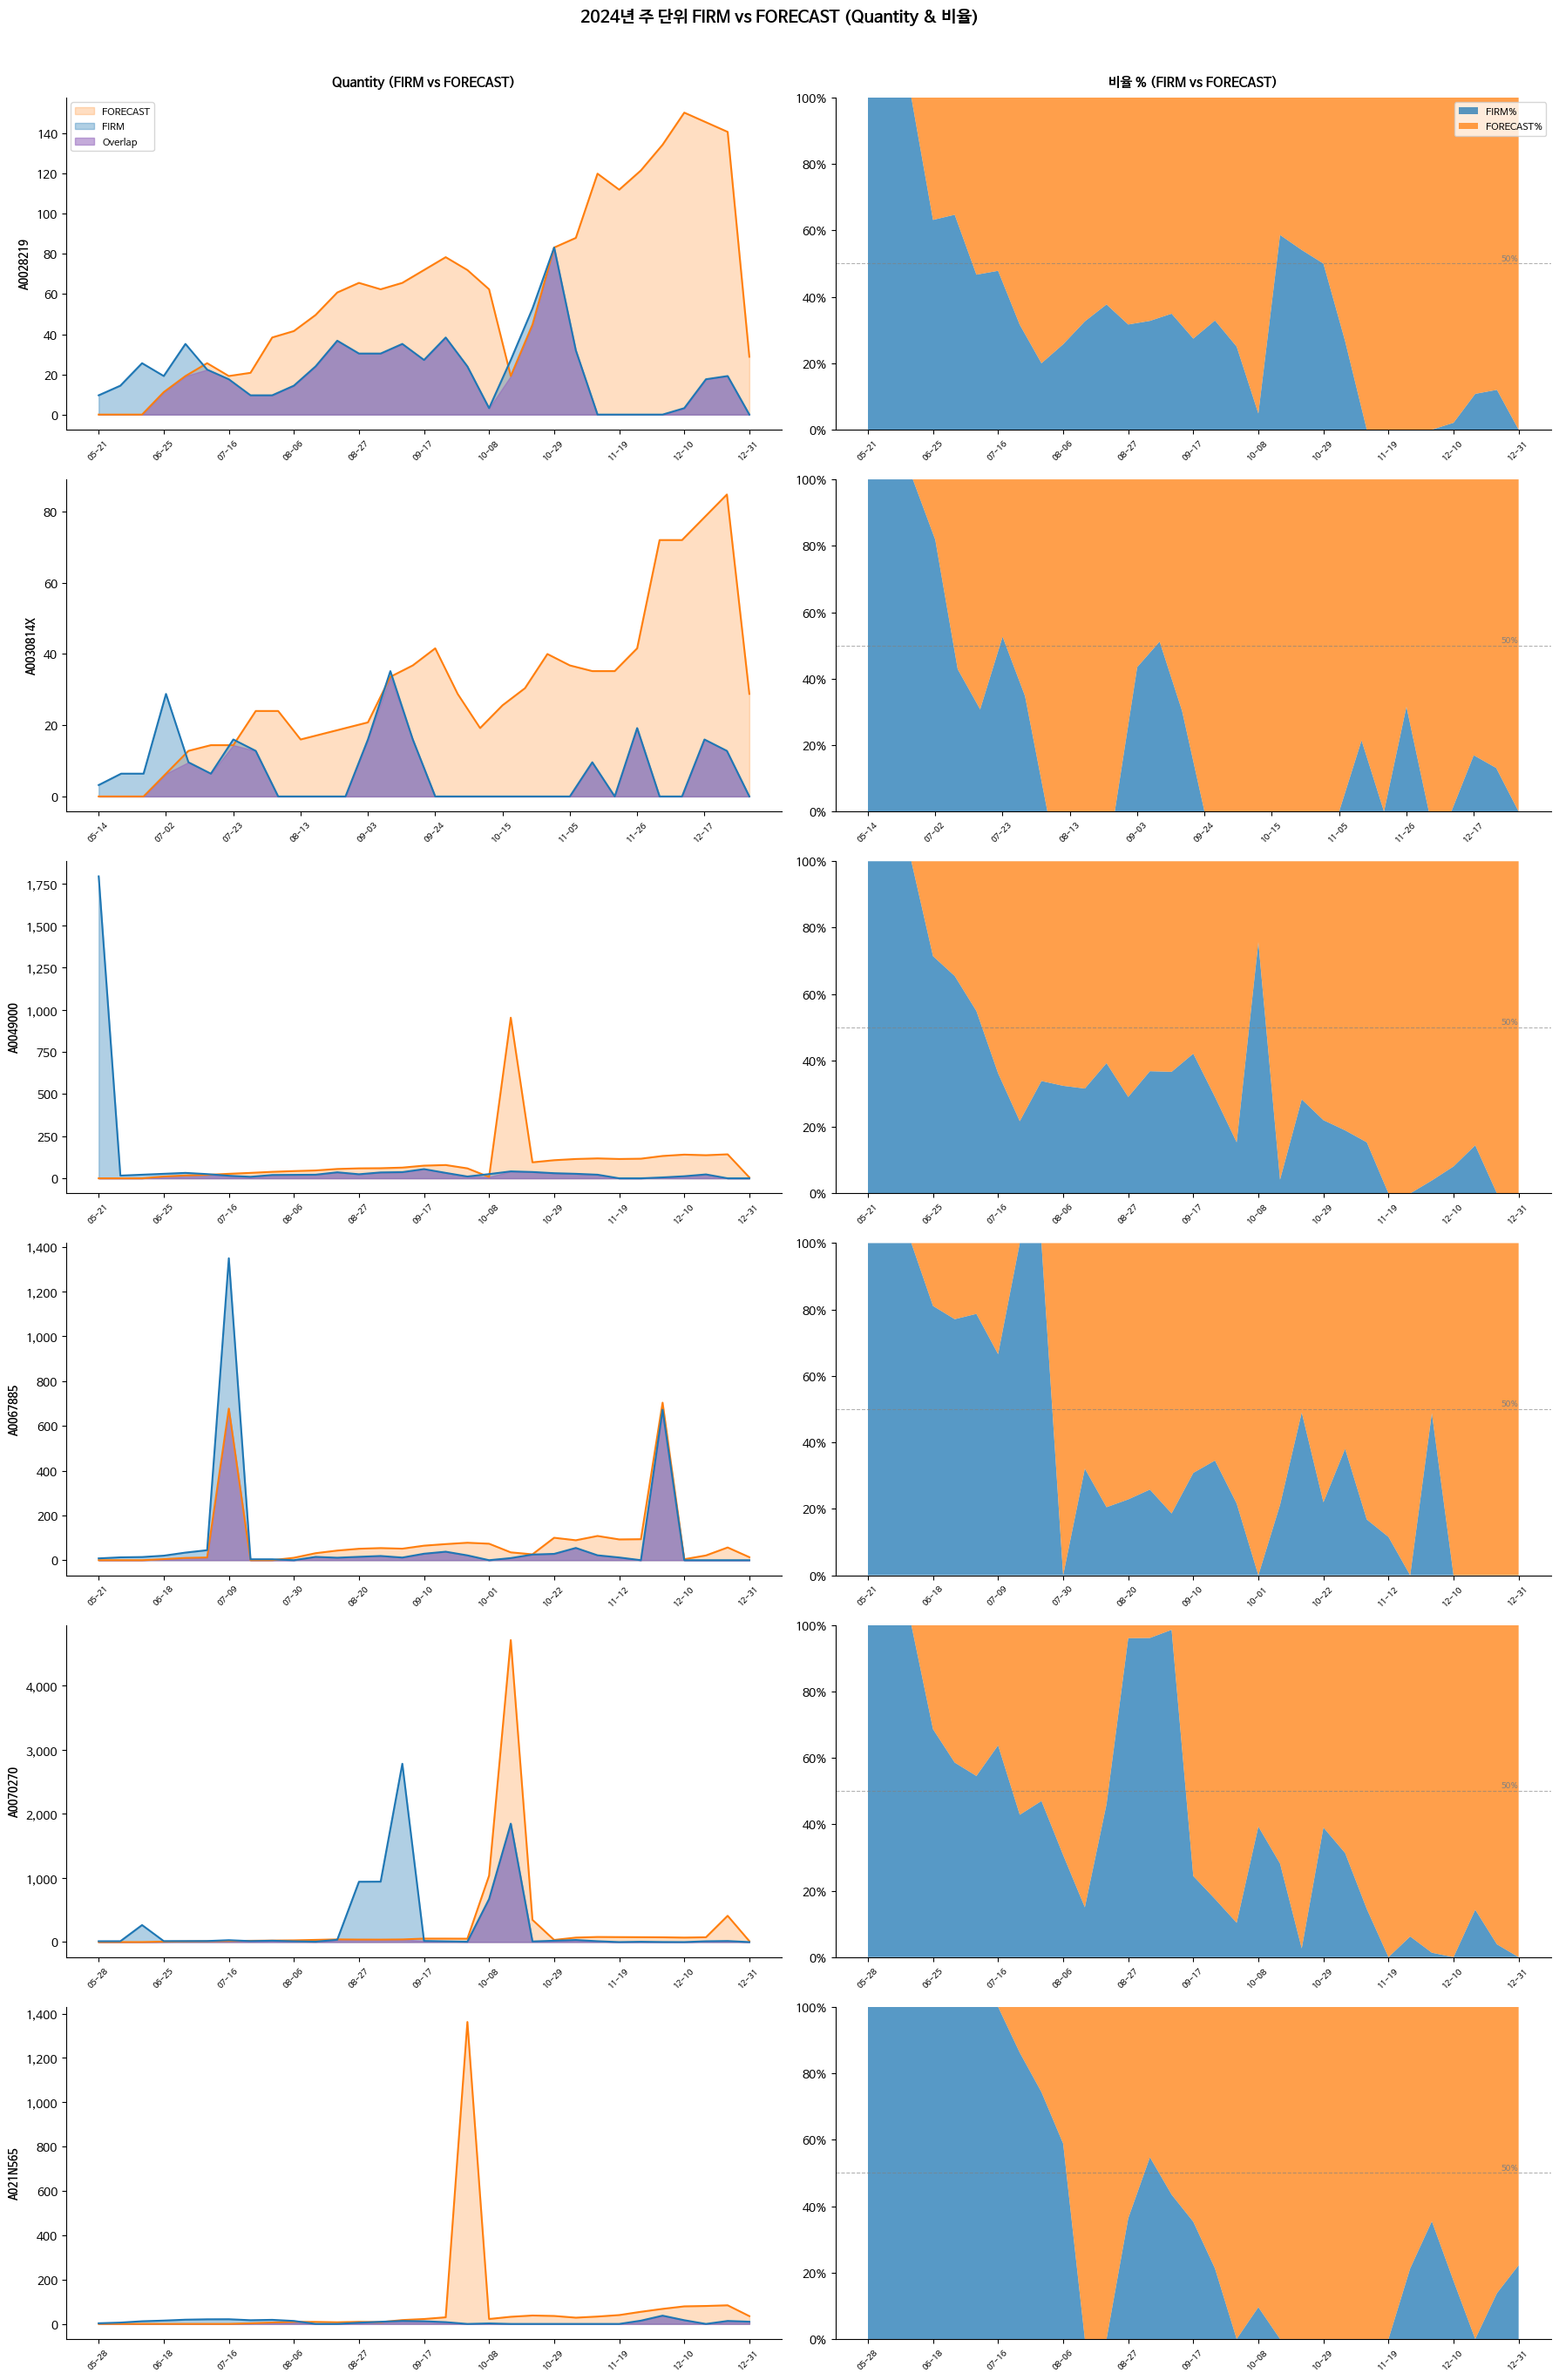

In [8]:
#  1. 날짜 변환
month_map = {
    'Jan':1, 'Feb':2, 'Mar':3, 'Apr':4,
    'May':5, 'Jun':6, 'Jul':7, 'Aug':8,
    'Sep':9, 'Oct':10, 'Nov':11, 'Dec':12
}

df['Month']     = df['Month'].astype(str).str.strip().str[:3].str.title()
df['Month_num'] = df['Month'].map(month_map)
df['Date']      = pd.to_datetime(
    dict(year=df['Year'], month=df['Month_num'], day=df['Day']),
    errors='coerce'
)

#  2. 2024년 필터 & PN 선택
df_2024 = df[df['Date'].dt.year == 2024].copy()
PN_LIST = df_2024['ZF_PN'].unique()[:6]

#  3. 색상 설정
COLORS = {
    'FIRM':     '#1f77b4',   # 파랑
    'FORECAST': '#ff7f0e',   # 주황
    'OVERLAP':  '#9467bd',   # 보라 (겹침 강조)
    'bg':       'white'
}

#  4. Figure 구성: PN별로 행, 열은 [Quantity | 비율]
n = len(PN_LIST)
fig, axes = plt.subplots(n, 2, figsize=(18, 4.5 * n))
fig.patch.set_facecolor(COLORS['bg'])
fig.suptitle('2024년 주 단위 FIRM vs FORECAST (Quantity & 비율)', fontsize=14, fontweight='bold', y=1.01)

# 열 제목
axes[0][0].set_title('Quantity (FIRM vs FORECAST)', fontsize=11, fontweight='bold', pad=10)
axes[0][1].set_title('비율 % (FIRM vs FORECAST)', fontsize=11, fontweight='bold', pad=10)

for i, pn in enumerate(PN_LIST):
    g = df_2024[df_2024['ZF_PN'] == pn].copy()

    # 주 단위 집계
    g['Week'] = g['Date'].dt.to_period('W-MON').apply(lambda r: r.start_time)
    weekly = (
        g.groupby(['Week', 'Firm/Forecast'])['Quantity']
        .sum()
        .unstack(fill_value=0)
        .sort_index()
    )

    # FIRM / FORECAST 추출 (없는 컬럼은 0으로)
    firm_vals = weekly.get('FIRM',     pd.Series(dtype=float)).reindex(weekly.index, fill_value=0)
    fc_vals   = weekly.get('FORECAST', pd.Series(dtype=float)).reindex(weekly.index, fill_value=0)

    x = np.arange(len(weekly))

    #  x축 tick 설정 (공통)
    step       = max(1, len(weekly) // 10)
    tick_pos   = list(range(0, len(weekly), step))
    tick_labels = [pd.Timestamp(weekly.index[j]).strftime('%m-%d') for j in tick_pos]

    # 왼쪽: Quantity 그래프

    ax_q = axes[i][0]

    ax_q.fill_between(x, fc_vals.values,
                      color=COLORS['FORECAST'], alpha=0.25, label='FORECAST')
    ax_q.plot(x, fc_vals.values,
              color=COLORS['FORECAST'], linewidth=1.5)

    ax_q.fill_between(x, firm_vals.values,
                      color=COLORS['FIRM'], alpha=0.35, label='FIRM')
    ax_q.plot(x, firm_vals.values,
              color=COLORS['FIRM'], linewidth=1.5)

    # 겹치는 영역 (min값) 진하게 강조
    overlap = np.minimum(firm_vals.values, fc_vals.values)
    ax_q.fill_between(x, overlap,
                      color=COLORS['OVERLAP'], alpha=0.55, label='Overlap')

    ax_q.set_ylabel(pn, fontsize=9, fontweight='bold')
    ax_q.set_xticks(tick_pos)
    ax_q.set_xticklabels(tick_labels, rotation=45, fontsize=7)
    ax_q.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{int(v):,}'))
    ax_q.spines[['top', 'right']].set_visible(False)

    if i == 0:
        ax_q.legend(fontsize=8)

    # 오른쪽: 비율 그래프 (stacked 100%)
    ax_r = axes[i][1]

    total      = firm_vals.values + fc_vals.values
    ratio_firm = np.where(total > 0, firm_vals.values / total * 100, 0)
    ratio_fc   = np.where(total > 0, fc_vals.values  / total * 100, 0)

    ax_r.stackplot(
        x,
        ratio_firm,
        ratio_fc,
        labels=['FIRM%', 'FORECAST%'],
        colors=[COLORS['FIRM'], COLORS['FORECAST']],
        alpha=0.75
    )

    # 50% 기준선 (FIRM=FORECAST 균형선)
    ax_r.axhline(50, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
    ax_r.text(len(x) - 1, 51, '50%', fontsize=7, color='gray', ha='right')

    ax_r.set_ylim(0, 100)
    ax_r.set_xticks(tick_pos)
    ax_r.set_xticklabels(tick_labels, rotation=45, fontsize=7)
    ax_r.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax_r.spines[['top', 'right']].set_visible(False)

    if i == 0:
        ax_r.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()